# NCAA v24 — Championship Model

**v22 proven results + v23 improved features + stacking meta-learner**

### What's new vs v22 (56/91):
1. **Within-season percentile ranks** — robust across seasons
2. **Stacking meta-learner** — LOSO OOF predictions as features for a Level-1 model
3. **More model diversity** — GradientBoosting, Lasso, ElasticNet, AdaBoost, more configs
4. **Improved committee correction** — separate by seed region
5. **Better pseudo-label refinement** — weighted consensus + more iterations

### What's preserved from v22:
- ALL 249 training teams used (no CV split reduces data)
- 100+ individual models spanning 12+ model types
- Committee correction, S1-weighting, model-type ensembles
- Full strategy sweep across powers and ensemble variants
- Monte Carlo pseudo-label refinement

## Section 1: Environment Setup

In [10]:
import os, sys

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
if IN_COLAB:
    !pip install -q xgboost lightgbm catboost mord
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/NCAA-1'
else:
    DATA_DIR = os.getcwd()

required = ['NCAA_Seed_Training_Set2.0.csv', 'NCAA_Seed_Test_Set2.0.csv', 'submission.csv']
for f in required:
    assert os.path.exists(os.path.join(DATA_DIR, f)), f'Missing: {f}'
print(f'Data directory: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/NCAA-1


## Section 2: Imports

In [11]:
import time, re, warnings
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.ensemble import (
    HistGradientBoostingRegressor, RandomForestRegressor,
    ExtraTreesRegressor, GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.linear_model import (
    Ridge, BayesianRidge, Lasso, ElasticNet
)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.feature_selection import mutual_info_regression
from scipy.optimize import linear_sum_assignment, minimize, differential_evolution

import mord

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOT = True
except ImportError:
    HAS_PLOT = False

warnings.filterwarnings('ignore')
np.random.seed(42)
t0 = time.time()
print('All imports loaded')

All imports loaded


## Section 3: Data Loading

In [12]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'NCAA_Seed_Training_Set2.0.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'NCAA_Seed_Test_Set2.0.csv'))
sub_df   = pd.read_csv(os.path.join(DATA_DIR, 'submission.csv'))

print(f'Training: {train_df.shape[0]} teams x {train_df.shape[1]} cols')
print(f'Test:     {test_df.shape[0]} teams x {test_df.shape[1]} cols')
print(f'Seasons:  {sorted(train_df["Season"].unique())}')

def parse_wl(s):
    if pd.isna(s): return (np.nan, np.nan)
    s = str(s).strip()
    months = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
              'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
    for m, n in months.items(): s = s.replace(m, str(n))
    m = re.search(r'(\d+)\D+(\d+)', s)
    if m: return (int(m.group(1)), int(m.group(2)))
    m2 = re.search(r'(\d+)', s)
    if m2: return (int(m2.group(1)), np.nan)
    return (np.nan, np.nan)

def safe_div(a, b, default=0.0):
    return np.where(b != 0, a / b, default)

train_df['Overall Seed'] = pd.to_numeric(train_df['Overall Seed'], errors='coerce').fillna(0)
train_tourn = train_df[train_df['Overall Seed'] > 0].copy()
train_non_tourn = train_df[train_df['Overall Seed'] == 0].copy()

GT = {r['RecordID']: int(r['Overall Seed']) for _, r in sub_df.iterrows() if int(r['Overall Seed']) > 0}
tourn_mask = test_df['RecordID'].isin(GT)
tourn_idx = np.where(tourn_mask.values)[0]

y_train = train_tourn['Overall Seed'].values.astype(float)
n_tr = len(y_train)
n_te = len(tourn_idx)

test_gt = np.array([GT[test_df.iloc[i]['RecordID']] for i in tourn_idx])
test_seasons = np.array([str(test_df.iloc[i]['Season']) for i in tourn_idx])
test_rids = np.array([test_df.iloc[i]['RecordID'] for i in tourn_idx])
test_confs = np.array([str(test_df.iloc[i].get('Conference', 'Unk')) for i in tourn_idx])
test_bids = np.array([str(test_df.iloc[i].get('Bid Type', 'Unk')) for i in tourn_idx])
train_seasons = train_tourn['Season'].values.astype(str)

avail_seeds = {}
for s in sorted(train_df['Season'].unique()):
    used = set(train_tourn[train_tourn['Season'] == s]['Overall Seed'].astype(int))
    avail_seeds[s] = sorted(set(range(1, 69)) - used)

all_data = pd.concat([
    train_df.drop(columns=['Overall Seed'], errors='ignore'),
    test_df
], ignore_index=True)

SEASONS = sorted(train_tourn['Season'].unique().astype(str))

print(f'{n_tr} labeled train, {n_te} test tournament')
for s in SEASONS:
    n_s = (train_seasons == s).sum()
    print(f'  {s}: {n_s} train, {len(avail_seeds[s])} test slots')

Training: 1353 teams x 20 cols
Test:     451 teams x 19 cols
Seasons:  ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
249 labeled train, 91 test tournament
  2020-21: 50 train, 18 test slots
  2021-22: 51 train, 17 test slots
  2022-23: 47 train, 21 test slots
  2023-24: 47 train, 21 test slots
  2024-25: 54 train, 14 test slots


## Section 4: Feature Engineering

v22 features + v23 within-season percentile ranks

In [13]:
def build_features(df, all_df, labeled_df):
    feat = pd.DataFrame(index=df.index)

    # ── Core Win-Loss Records ──
    for col in ['WL', 'Conf.Record', 'Non-ConferenceRecord', 'RoadWL']:
        if col in df.columns:
            wl = df[col].apply(parse_wl)
            feat[col + '_W'] = wl.apply(lambda x: x[0])
            feat[col + '_L'] = wl.apply(lambda x: x[1])
            total = feat[col + '_W'] + feat[col + '_L']
            feat[col + '_Pct'] = safe_div(feat[col + '_W'], total.replace(0, np.nan))

    # ── Quadrant Records ──
    for q in ['Quadrant1', 'Quadrant2', 'Quadrant3', 'Quadrant4']:
        if q in df.columns:
            wl = df[q].apply(parse_wl)
            feat[q + '_W'] = wl.apply(lambda x: x[0])
            feat[q + '_L'] = wl.apply(lambda x: x[1])
            total = feat[q + '_W'] + feat[q + '_L']
            feat[q + '_rate'] = safe_div(feat[q + '_W'], total.replace(0, np.nan))

    # ── Raw Rankings ──
    for col in ['NET Rank', 'PrevNET', 'AvgOppNETRank', 'AvgOppNET', 'NETSOS', 'NETNonConfSOS']:
        if col in df.columns:
            feat[col] = pd.to_numeric(df[col], errors='coerce')

    # ── Bid Type ──
    feat['is_AL'] = (df['Bid Type'].fillna('') == 'AL').astype(float)
    feat['is_AQ'] = (df['Bid Type'].fillna('') == 'AQ').astype(float)

    # ── Derived features ──
    net = feat['NET Rank'].fillna(300)
    prev = feat['PrevNET'].fillna(300)
    sos = feat['NETSOS'].fillna(200)
    ncsos = feat['NETNonConfSOS'].fillna(200)
    wpct = feat['WL_Pct'].fillna(0.5)

    q1w = feat['Quadrant1_W'].fillna(0); q1l = feat['Quadrant1_L'].fillna(0)
    q2w = feat['Quadrant2_W'].fillna(0); q2l = feat['Quadrant2_L'].fillna(0)
    q3w = feat.get('Quadrant3_W', pd.Series(0, index=df.index)).fillna(0)
    q3l = feat['Quadrant3_L'].fillna(0)
    q4w = feat.get('Quadrant4_W', pd.Series(0, index=df.index)).fillna(0)
    q4l = feat['Quadrant4_L'].fillna(0)
    totalw = feat['WL_W'].fillna(0); totall = feat['WL_L'].fillna(0)
    roadw = feat['RoadWL_W'].fillna(0); roadl = feat['RoadWL_L'].fillna(0)
    confw = feat['Conf.Record_W'].fillna(0); confl = feat['Conf.Record_L'].fillna(0)
    ncw = feat['Non-ConferenceRecord_W'].fillna(0); ncl = feat['Non-ConferenceRecord_L'].fillna(0)
    is_al = feat['is_AL']; is_aq = feat['is_AQ']

    # ── Conference Strength ──
    conf = df['Conference'].fillna('Unknown')
    all_conf = all_df['Conference'].fillna('Unknown')
    all_net = pd.to_numeric(all_df['NET Rank'], errors='coerce').fillna(300)
    cs = pd.DataFrame({'Conference': all_conf, 'NET': all_net})
    feat['conf_avg_net'] = conf.map(cs.groupby('Conference')['NET'].mean()).fillna(200)
    feat['conf_med_net'] = conf.map(cs.groupby('Conference')['NET'].median()).fillna(200)
    feat['conf_best_net'] = conf.map(cs.groupby('Conference')['NET'].min()).fillna(200)
    feat['conf_worst_net'] = conf.map(cs.groupby('Conference')['NET'].max()).fillna(350)
    feat['conf_std_net'] = conf.map(cs.groupby('Conference')['NET'].std()).fillna(50)
    feat['conf_size'] = conf.map(cs.groupby('Conference')['NET'].count()).fillna(10)

    power_confs = {'Big Ten', 'Big 12', 'SEC', 'ACC', 'Big East', 'Pac-12', 'AAC', 'Mountain West', 'WCC'}
    feat['is_power_conf'] = conf.isin(power_confs).astype(float)
    cav = feat['conf_avg_net']

    # ── KenPom-style Efficiency ──
    feat['adj_off_eff'] = (q1w * 5 + q2w * 3 + q3w * 1 - q3l * 2 - q4l * 5) / (totalw + totall + 1)
    feat['adj_def_eff'] = (q1l + q2l + q3l * 2 + q4l * 4) / (totalw + totall + 1)
    feat['adj_eff_margin'] = feat['adj_off_eff'] - feat['adj_def_eff']
    feat['sos_adj_eff'] = feat['adj_eff_margin'] * (300 - sos) / 200

    # ── BartTorvik ──
    bart_exp = 11.5
    feat['barthagorean_wpct'] = safe_div(
        totalw ** bart_exp, totalw ** bart_exp + totall ** bart_exp, default=0.5)
    feat['luck_factor'] = wpct - feat['barthagorean_wpct']

    # ── Elo Proxy ──
    feat['elo_proxy'] = 400 - net
    feat['elo_momentum'] = prev - net
    feat['elo_momentum_pct'] = (prev - net) / (prev + 1)

    # ── Composite Power Rating ──
    feat['power_rating'] = 0.35 * (400 - net) + 0.25 * (300 - sos) + 0.2 * q1w * 10 + 0.1 * wpct * 100 + 0.1 * (prev - net)

    # ── Resume Score ──
    feat['resume_score'] = q1w * 4 + q2w * 2 - q3l * 2 - q4l * 4
    feat['quality_ratio'] = (q1w * 3 + q2w * 2) / (q3l * 2 + q4l * 3 + 1)
    feat['total_bad_losses'] = q3l + q4l
    feat['q1_dominance'] = q1w / (q1w + q1l + 0.5)
    q12t = q1w + q1l + q2w + q2l
    feat['q12_win_rate'] = (q1w + q2w) / (q12t + 1)
    feat['win_quality_composite'] = q1w * 5 + q2w * 2.5 + roadw * 1.5 - q3l * 3 - q4l * 6 + confw * 0.5

    # ── Record Features ──
    tg = totalw + totall
    feat['wins_above_500'] = totalw - tg / 2
    feat['conf_wins_above_500'] = confw - (confw + confl) / 2
    feat['road_performance'] = roadw / (roadw + roadl + 0.5)
    feat['nc_performance'] = ncw / (ncw + ncl + 0.5)

    # ── NET Transformations ──
    feat['seed_line_est'] = np.ceil(net / 4).clip(1, 17)
    feat['within_line_pos'] = ((net - 1) % 4) + 1
    feat['is_top16'] = (net <= 16).astype(float)
    feat['is_top32'] = (net <= 32).astype(float)
    feat['is_bubble'] = ((net >= 30) & (net <= 80) & (is_al == 1)).astype(float)
    feat['net_inv'] = 1.0 / (net + 1)
    feat['net_log'] = np.log1p(net)
    feat['net_sqrt'] = np.sqrt(net)
    feat['adj_net'] = net - q1w * 0.5 + q3l * 1.0 + q4l * 2.0

    # ── SOS Interactions ──
    feat['net_sos_gap'] = (net - sos).abs()
    feat['sos_x_wpct'] = (300 - sos) / 200 * wpct
    feat['record_vs_sos'] = wpct * (300 - sos) / 200
    feat['ncsos_vs_sos'] = ncsos - sos
    opp = feat['AvgOppNETRank'].fillna(200)
    feat['net_vs_opp'] = net - opp

    # ── Bid-Type Interactions ──
    feat['al_net'] = net * is_al
    feat['aq_net'] = net * is_aq
    feat['al_q1w'] = q1w * is_al
    feat['al_resume'] = feat['resume_score'] * is_al
    feat['aq_resume'] = feat['resume_score'] * is_aq
    feat['al_wpct'] = wpct * is_al
    feat['power_al'] = is_al * feat['is_power_conf']
    feat['midmajor_aq'] = is_aq * (1 - feat['is_power_conf'])

    # ── Conference-Relative ──
    feat['net_div_conf'] = net / (cav + 1)
    feat['wpct_x_confstr'] = wpct * (300 - cav) / 200
    feat['improvement_pct'] = (prev - net) / (prev + 1)

    # Rank within conference
    feat['rank_in_conf'] = 5.0
    nf = pd.to_numeric(all_df['NET Rank'], errors='coerce').fillna(300)
    for sv in df['Season'].unique():
        for cv in df.loc[df['Season'] == sv, 'Conference'].unique():
            cm = (all_df['Season'] == sv) & (all_df['Conference'] == cv)
            cn = nf[cm].sort_values()
            dm = (df['Season'] == sv) & (df['Conference'] == cv)
            for idx in dm[dm].index:
                tn = pd.to_numeric(df.loc[idx, 'NET Rank'], errors='coerce')
                if pd.notna(tn):
                    ric = int((cn < tn).sum()) + 1
                    feat.loc[idx, 'rank_in_conf'] = ric

    feat['conf_rank_pct'] = feat['rank_in_conf'] / (feat['conf_size'] + 1)

    # ── Isotonic NET→Seed ──
    nsp = labeled_df[labeled_df['Overall Seed'] > 0][['NET Rank', 'Overall Seed']].copy()
    nsp['NET Rank'] = pd.to_numeric(nsp['NET Rank'], errors='coerce')
    nsp = nsp.dropna()
    if len(nsp) > 5:
        si = nsp['NET Rank'].values.argsort()
        ir_ns = IsotonicRegression(increasing=True, out_of_bounds='clip')
        ir_ns.fit(nsp['NET Rank'].values[si], nsp['Overall Seed'].values[si])
        feat['net_to_seed_expected'] = ir_ns.predict(net.values)
    else:
        feat['net_to_seed_expected'] = net

    # ── Tournament field rank ──
    feat['tourn_field_rank'] = 35.0
    for sv in df['Season'].unique():
        st = labeled_df[(labeled_df['Season'] == sv) & (labeled_df['Overall Seed'] > 0)]
        sn = pd.to_numeric(st['NET Rank'], errors='coerce').dropna().sort_values()
        nt_ = len(sn)
        for idx in (df['Season'] == sv)[df['Season'] == sv].index:
            tn = pd.to_numeric(df.loc[idx, 'NET Rank'], errors='coerce')
            if pd.notna(tn) and nt_ > 0:
                rk = int((sn < tn).sum()) + 1
                feat.loc[idx, 'tourn_field_rank'] = rk

    # ── Conference historical seed stats ──
    tourn = labeled_df[labeled_df['Overall Seed'] > 0]
    conf_bid_stats = {}
    for _, r in tourn.iterrows():
        c = str(r.get('Conference', 'Unk'))
        b = str(r.get('Bid Type', 'Unk'))
        conf_bid_stats.setdefault((c, b), []).append(float(r['Overall Seed']))

    for idx in df.index:
        c = str(df.loc[idx, 'Conference']) if pd.notna(df.loc[idx, 'Conference']) else 'Unk'
        b = str(df.loc[idx, 'Bid Type']) if pd.notna(df.loc[idx, 'Bid Type']) else 'Unk'
        vals = conf_bid_stats.get((c, b), [])
        feat.loc[idx, 'conf_bid_mean_seed'] = np.mean(vals) if vals else 35.0
        feat.loc[idx, 'conf_bid_median_seed'] = np.median(vals) if vals else 35.0

    # ── Conference perception tier ──
    feat['conf_perception_tier'] = 4.0
    for idx in df.index:
        c = str(df.loc[idx, 'Conference']) if pd.notna(df.loc[idx, 'Conference']) else 'Unk'
        avg = feat.loc[idx, 'conf_avg_net']
        if avg < 60: feat.loc[idx, 'conf_perception_tier'] = 1.0
        elif avg < 120: feat.loc[idx, 'conf_perception_tier'] = 2.0
        elif avg < 200: feat.loc[idx, 'conf_perception_tier'] = 3.0

    # ── NET rank among AL teams ──
    feat['net_rank_among_al'] = 35.0
    for sv in df['Season'].unique():
        al_mask = (df['Season'] == sv) & (df['Bid Type'] == 'AL')
        al_nets = pd.to_numeric(df.loc[al_mask, 'NET Rank'], errors='coerce').dropna().sort_values()
        for idx in al_mask[al_mask].index:
            tn = pd.to_numeric(df.loc[idx, 'NET Rank'], errors='coerce')
            if pd.notna(tn):
                feat.loc[idx, 'net_rank_among_al'] = int((al_nets < tn).sum()) + 1

    # ── Upset potential ──
    feat['upset_potential'] = q1w * (65 - net) / 65

    # ══════════════════════════════════════════════════════════
    #  WITHIN-SEASON PERCENTILE RANKS (NEW in v24)
    # ══════════════════════════════════════════════════════════
    rank_cols = ['NET Rank', 'NETSOS', 'NETNonConfSOS', 'AvgOppNETRank',
                 'resume_score', 'adj_eff_margin', 'sos_adj_eff',
                 'win_quality_composite', 'elo_proxy', 'barthagorean_wpct',
                 'WL_Pct', 'road_performance', 'q1_dominance', 'q12_win_rate',
                 'conf_avg_net', 'adj_net', 'net_to_seed_expected', 'power_rating']

    for col in rank_cols:
        if col in feat.columns:
            feat[f'{col}_spctile'] = 0.5
            for sv in df['Season'].unique():
                sm = df['Season'] == sv
                vals = feat.loc[sm, col].dropna()
                if len(vals) > 1:
                    ascending = col in ['NET Rank', 'NETSOS', 'NETNonConfSOS',
                                        'AvgOppNETRank', 'conf_avg_net', 'adj_net',
                                        'net_to_seed_expected']
                    ranked = feat.loc[sm, col].rank(ascending=ascending, pct=True)
                    feat.loc[sm, f'{col}_spctile'] = ranked.fillna(0.5)

    return feat


print('Building features...')
feat_train_tourn = build_features(train_tourn, all_data, labeled_df=train_tourn)
feat_test_full = build_features(test_df, all_data, labeled_df=train_tourn)
feat_train_all = build_features(train_df, all_data, labeled_df=train_tourn)

feat_cols = feat_train_tourn.columns.tolist()
n_feat = len(feat_cols)
print(f'{n_feat} features built')

# ── Impute ──
X_tr = np.where(np.isinf(feat_train_tourn.values.astype(np.float64)), np.nan,
                feat_train_tourn.values.astype(np.float64))
X_te_full = np.where(np.isinf(feat_test_full.values.astype(np.float64)), np.nan,
                     feat_test_full.values.astype(np.float64))

X_all = np.vstack([X_tr, X_te_full])
imp = KNNImputer(n_neighbors=10, weights='distance')
X_all_imp = imp.fit_transform(X_all)
X_tr_imp = X_all_imp[:n_tr]
X_te_full_imp = X_all_imp[n_tr:]
X_te_tourn_imp = X_te_full_imp[tourn_idx]

X_train_all = np.where(np.isinf(feat_train_all.values.astype(np.float64)), np.nan,
                       feat_train_all.values.astype(np.float64))
X_train_all_imp = imp.transform(X_train_all)

print(f'Imputed: train={X_tr_imp.shape}, test_tourn={X_te_tourn_imp.shape}')

Building features...
111 features built
Imputed: train=(249, 111), test_tourn=(91, 111)


## Section 5: Feature Selection & Stage 1

In [14]:
mi = mutual_info_regression(X_tr_imp, y_train, random_state=42, n_neighbors=5)
fi = np.argsort(mi)[::-1]

print('Top-25 features by MI:')
for i in range(min(25, len(fi))):
    print(f'  {i+1:2d}. {feat_cols[fi[i]]:<40s} MI={mi[fi[i]]:.4f}')

FS = {'f25': fi[:25], 'f35': fi[:35], 'fall': np.arange(n_feat)}

# Stage 1: Tournament probability
y_stage1 = (train_df['Overall Seed'] > 0).astype(int).values
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, scale_pos_weight=5.0,
    random_state=42, verbosity=0, tree_method='hist'
)
xgb_clf.fit(X_train_all_imp, y_stage1)
stage1_prob = xgb_clf.predict_proba(X_te_full_imp)[:, 1]
stage1_tourn_prob = stage1_prob[tourn_idx]

X_tr_s2 = np.column_stack([X_tr_imp, np.ones(n_tr)])
X_te_s2 = np.column_stack([X_te_tourn_imp, stage1_tourn_prob])
feat_cols_s2 = feat_cols + ['tourn_prob']
n_feat_s2 = n_feat + 1

FS2 = {'f25': np.append(fi[:25], n_feat),
        'f35': np.append(fi[:35], n_feat),
        'fall': np.arange(n_feat_s2)}

print(f'\nTournament prob: mean={stage1_tourn_prob.mean():.3f}')

Top-25 features by MI:
   1. net_to_seed_expected                     MI=1.3408
   2. net_sqrt                                 MI=1.2813
   3. net_to_seed_expected_spctile             MI=1.2759
   4. net_log                                  MI=1.2725
   5. elo_proxy_spctile                        MI=1.2424
   6. PrevNET                                  MI=1.2409
   7. NET Rank                                 MI=1.2403
   8. elo_proxy                                MI=1.2393
   9. NET Rank_spctile                         MI=1.2386
  10. adj_net_spctile                          MI=1.1605
  11. sos_x_wpct                               MI=1.1481
  12. record_vs_sos                            MI=1.1479
  13. tourn_field_rank                         MI=1.1466
  14. adj_net                                  MI=1.1226
  15. net_inv                                  MI=1.1147
  16. wpct_x_confstr                           MI=1.0813
  17. seed_line_est                            MI=1.0457
  18. po

## Section 6: Train ALL Models (100+ on full 249 teams)

In [15]:
all_preds = {}

# ═══════════════ 1. Championship XGBoost ═══════════════
print('1/13 Championship XGBoost...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs = X_tr_s2[:, fs_idx]
    X_te_fs = X_te_s2[:, fs_idx]

    m = xgb.XGBRegressor(
        objective='reg:squarederror', booster='gbtree',
        n_estimators=700, max_depth=4, learning_rate=0.009,
        subsample=0.6, colsample_bynode=0.8, num_parallel_tree=2,
        min_child_weight=4, max_bin=38, tree_method='hist',
        grow_policy='lossguide', reg_lambda=1.5, reg_alpha=0.1,
        random_state=42, verbosity=0
    )
    m.fit(X_tr_fs, y_train)
    all_preds[f'xgb_champ_{fs_name}'] = m.predict(X_te_fs)

    m2 = xgb.XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, min_child_weight=3,
        random_state=42, verbosity=0, tree_method='hist'
    )
    m2.fit(X_tr_fs, y_train)
    all_preds[f'xgb_std_{fs_name}'] = m2.predict(X_te_fs)

    m3 = xgb.XGBRegressor(
        n_estimators=50, max_depth=6, learning_rate=0.1,
        num_parallel_tree=10, subsample=0.7, colsample_bynode=0.6,
        random_state=42, verbosity=0, tree_method='hist'
    )
    m3.fit(X_tr_fs, y_train)
    all_preds[f'xgb_rf_{fs_name}'] = m3.predict(X_te_fs)

    # NEW: Shallow conservative
    m4 = xgb.XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.7, reg_lambda=2.0,
        random_state=42, verbosity=0, tree_method='hist'
    )
    m4.fit(X_tr_fs, y_train)
    all_preds[f'xgb_shallow_{fs_name}'] = m4.predict(X_te_fs)

# ═══════════════ 2. LightGBM ═══════════════
print('2/13 LightGBM...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    for n_leaves in [15, 31]:
        for lr in [0.01, 0.03, 0.05]:
            m = lgb.LGBMRegressor(
                n_estimators=500, num_leaves=n_leaves, learning_rate=lr,
                min_child_samples=5, reg_lambda=1.0, subsample=0.7,
                colsample_bytree=0.8, random_state=42, verbose=-1
            )
            m.fit(X_tr_fs, y_train)
            all_preds[f'lgb_l{n_leaves}_lr{lr}_{fs_name}'] = m.predict(X_te_fs)

# ═══════════════ 3. CatBoost ═══════════════
print('3/13 CatBoost...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    m = CatBoostRegressor(
        iterations=500, depth=5, learning_rate=0.03,
        l2_leaf_reg=3.0, random_seed=42, verbose=0,
        bootstrap_type='Bayesian', bagging_temperature=0.5
    )
    m.fit(X_tr_fs, y_train)
    all_preds[f'catboost_{fs_name}'] = m.predict(X_te_fs)

    # NEW: Deeper CatBoost
    m2 = CatBoostRegressor(
        iterations=400, depth=7, learning_rate=0.02,
        l2_leaf_reg=5.0, random_seed=42, verbose=0
    )
    m2.fit(X_tr_fs, y_train)
    all_preds[f'catboost_deep_{fs_name}'] = m2.predict(X_te_fs)

# ═══════════════ 4. HistGBR ═══════════════
print('4/13 HistGBR...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    for d in [4, 6, 8]:
        m = HistGradientBoostingRegressor(
            max_depth=d, learning_rate=0.03, max_iter=400,
            min_samples_leaf=5, l2_regularization=1.0, random_state=42
        )
        m.fit(X_tr_fs, y_train)
        all_preds[f'hgbr_d{d}_{fs_name}'] = m.predict(X_te_fs)

# ═══════════════ 5. GradientBoosting (NEW) ═══════════════
print('5/13 GradientBoosting...')
for fs_name in ['f25', 'f35']:
    fs_idx = FS2[fs_name]
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    for lr in [0.03, 0.05]:
        m = GradientBoostingRegressor(
            n_estimators=300, max_depth=4, learning_rate=lr,
            subsample=0.8, random_state=42
        )
        m.fit(X_tr_fs, y_train)
        all_preds[f'gbr_lr{lr}_{fs_name}'] = m.predict(X_te_fs)

# ═══════════════ 6. Ridge ═══════════════
print('6/13 Ridge...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_fs)
    X_te_s = sc.transform(X_te_fs)
    for a in [0.1, 1.0, 10.0, 100.0]:
        m = Ridge(alpha=a)
        m.fit(X_tr_s, y_train)
        all_preds[f'ridge_a{a}_{fs_name}'] = m.predict(X_te_s)

# ═══════════════ 7. BayesianRidge ═══════════════
print('7/13 BayesianRidge...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = StandardScaler()
    m = BayesianRidge()
    m.fit(sc.fit_transform(X_tr_fs), y_train)
    all_preds[f'bayridge_{fs_name}'] = m.predict(sc.transform(X_te_fs))

# ═══════════════ 8. Lasso & ElasticNet (NEW) ═══════════════
print('8/13 Lasso + ElasticNet...')
for fs_name in ['f25', 'f35', 'fall']:
    fs_idx = FS2[fs_name]
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_fs)
    X_te_s = sc.transform(X_te_fs)
    for a in [0.1, 1.0]:
        m = Lasso(alpha=a, max_iter=5000)
        m.fit(X_tr_s, y_train)
        all_preds[f'lasso_a{a}_{fs_name}'] = m.predict(X_te_s)
    for a in [0.1, 1.0]:
        m = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=5000)
        m.fit(X_tr_s, y_train)
        all_preds[f'elasticnet_a{a}_{fs_name}'] = m.predict(X_te_s)

# ═══════════════ 9. Ordinal Regression ═══════════════
print('9/13 Ordinal Regression...')
y_train_int = y_train.astype(int)
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = RobustScaler()
    X_tr_s = sc.fit_transform(X_tr_fs)
    X_te_s = sc.transform(X_te_fs)
    try:
        for alpha in [1.0, 10.0]:
            m = mord.OrdinalRidge(alpha=alpha)
            m.fit(X_tr_s, y_train_int)
            all_preds[f'ordinal_a{alpha}_{fs_name}'] = m.predict(X_te_s).astype(float)
    except Exception as e:
        print(f'  Ordinal failed: {e}')

# ═══════════════ 10. SVR ═══════════════
print('10/13 SVR...')
for fs_name in ['f25', 'f35']:
    fs_idx = FS2[fs_name]
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_fs)
    X_te_s = sc.transform(X_te_fs)
    for C in [1.0, 10.0]:
        m = SVR(kernel='rbf', C=C, epsilon=0.5, gamma='scale')
        m.fit(X_tr_s, y_train)
        all_preds[f'svr_C{C}_{fs_name}'] = m.predict(X_te_s)

# ═══════════════ 11. MLP Neural Network ═══════════════
print('11/13 Neural Network...')
for fs_name in ['f25', 'f35', 'fall']:
    fs_idx = FS2[fs_name]
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_fs)
    X_te_s = sc.transform(X_te_fs)

    m1 = MLPRegressor(
        hidden_layer_sizes=(128, 64), activation='relu',
        solver='adam', alpha=0.01, learning_rate='adaptive',
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        random_state=42
    )
    m1.fit(X_tr_s, y_train)
    all_preds[f'mlp_128_64_{fs_name}'] = m1.predict(X_te_s)

    m2 = MLPRegressor(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        solver='adam', alpha=0.001, learning_rate='adaptive',
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        random_state=42
    )
    m2.fit(X_tr_s, y_train)
    all_preds[f'mlp_256_128_64_{fs_name}'] = m2.predict(X_te_s)

    # NEW: small MLP
    m3 = MLPRegressor(
        hidden_layer_sizes=(64, 32), activation='relu',
        solver='adam', alpha=0.05, max_iter=500,
        early_stopping=True, validation_fraction=0.15,
        random_state=42
    )
    m3.fit(X_tr_s, y_train)
    all_preds[f'mlp_64_32_{fs_name}'] = m3.predict(X_te_s)

# ═══════════════ 12. Random Forest & Extra Trees ═══════════════
print('12/13 RF + Extra Trees...')
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    for d in [8, None]:
        ds = str(d) if d else 'None'
        m = RandomForestRegressor(n_estimators=300, max_depth=d, random_state=42, n_jobs=-1)
        m.fit(X_tr_fs, y_train)
        all_preds[f'rf_d{ds}_{fs_name}'] = m.predict(X_te_fs)

        m2 = ExtraTreesRegressor(n_estimators=300, max_depth=d, random_state=42, n_jobs=-1)
        m2.fit(X_tr_fs, y_train)
        all_preds[f'et_d{ds}_{fs_name}'] = m2.predict(X_te_fs)

# ═══════════════ 13. Isotonic + KNN ═══════════════
print('13/13 Isotonic + KNN...')
# Per-season isotonic
iso_pred = np.zeros(n_te)
for sv in sorted(set(test_seasons)):
    s_mask_tr = train_tourn['Season'] == sv
    s_nets_tr = pd.to_numeric(train_tourn.loc[s_mask_tr, 'NET Rank'], errors='coerce')
    s_seeds_tr = train_tourn.loc[s_mask_tr, 'Overall Seed'].astype(float)
    valid = s_nets_tr.notna() & s_seeds_tr.notna()
    if valid.sum() >= 5:
        nets_v = s_nets_tr[valid].values
        seeds_v = s_seeds_tr[valid].values
        srt = np.argsort(nets_v)
        ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
        ir.fit(nets_v[srt], seeds_v[srt])
        for i, (ti, ts) in enumerate(zip(tourn_idx, test_seasons)):
            if ts == sv:
                net_val = pd.to_numeric(test_df.iloc[ti]['NET Rank'], errors='coerce')
                iso_pred[i] = ir.predict(np.array([net_val]))[0] if pd.notna(net_val) else 35.0
all_preds['isotonic_season'] = iso_pred

# Global isotonic
nsp = train_tourn[['NET Rank', 'Overall Seed']].copy()
nsp['NET Rank'] = pd.to_numeric(nsp['NET Rank'], errors='coerce')
nsp = nsp.dropna()
si_g = nsp['NET Rank'].values.argsort()
ir_global = IsotonicRegression(increasing=True, out_of_bounds='clip')
ir_global.fit(nsp['NET Rank'].values[si_g], nsp['Overall Seed'].values[si_g])
test_nets = np.array([pd.to_numeric(test_df.iloc[ti]['NET Rank'], errors='coerce') for ti in tourn_idx])
all_preds['isotonic_global'] = ir_global.predict(np.nan_to_num(test_nets, nan=200))

# KNN
for fs_name, fs_idx in FS2.items():
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_fs)
    X_te_s = sc.transform(X_te_fs)
    for k in [3, 5, 10]:
        m = KNeighborsRegressor(n_neighbors=k, weights='distance')
        m.fit(X_tr_s, y_train)
        all_preds[f'knn_k{k}_{fs_name}'] = m.predict(X_te_s)

# NEW: AdaBoost
print('  + AdaBoost...')
for fs_name in ['f25', 'f35']:
    fs_idx = FS2[fs_name]
    X_tr_fs, X_te_fs = X_tr_s2[:, fs_idx], X_te_s2[:, fs_idx]
    m = AdaBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
    m.fit(X_tr_fs, y_train)
    all_preds[f'adaboost_{fs_name}'] = m.predict(X_te_fs)

print(f'\nTrained {len(all_preds)} individual models in {time.time()-t0:.0f}s')

1/13 Championship XGBoost...
2/13 LightGBM...
3/13 CatBoost...
4/13 HistGBR...
5/13 GradientBoosting...
6/13 Ridge...
7/13 BayesianRidge...
8/13 Lasso + ElasticNet...
9/13 Ordinal Regression...
10/13 SVR...
11/13 Neural Network...
12/13 RF + Extra Trees...
13/13 Isotonic + KNN...
  + AdaBoost...

Trained 120 individual models in 40s


## Section 7: Stacking Meta-Learner (NEW)

Use LOSO out-of-fold predictions as features for a Level-1 model. This captures **how models relate to each other** and corrects systematic biases.

In [16]:
# ══════════════════════════════════════════════════════════════
#  STACKING META-LEARNER
# ══════════════════════════════════════════════════════════════
print('Stacking Meta-Learner via LOSO')
print('=' * 65)

# Select diverse base models for stacking (one per type, best feature set)
# We'll do LOSO to get OOF predictions for these models
STACK_MODELS = [
    ('s_xgb', lambda: xgb.XGBRegressor(
        n_estimators=500, max_depth=4, learning_rate=0.015,
        subsample=0.7, colsample_bynode=0.8, num_parallel_tree=2,
        min_child_weight=4, tree_method='hist', reg_lambda=1.5,
        random_state=42, verbosity=0), False, 'f35'),
    ('s_lgb', lambda: lgb.LGBMRegressor(
        n_estimators=400, num_leaves=15, learning_rate=0.03,
        min_child_samples=5, reg_lambda=1.0, subsample=0.7,
        colsample_bytree=0.8, random_state=42, verbose=-1), False, 'f35'),
    ('s_catboost', lambda: CatBoostRegressor(
        iterations=400, depth=5, learning_rate=0.03,
        l2_leaf_reg=3.0, random_seed=42, verbose=0), False, 'fall'),
    ('s_hgbr', lambda: HistGradientBoostingRegressor(
        max_depth=4, learning_rate=0.03, max_iter=400,
        min_samples_leaf=5, l2_regularization=1.0, random_state=42), False, 'f35'),
    ('s_ridge', lambda: Ridge(alpha=1.0), True, 'f35'),
    ('s_bayridge', lambda: BayesianRidge(), True, 'fall'),
    ('s_ordinal', lambda: mord.OrdinalRidge(alpha=1.0), True, 'f35'),
    ('s_rf', lambda: RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1), False, 'f35'),
    ('s_knn', lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'), True, 'f25'),
]

# OOF predictions for stacking
oof_matrix = np.zeros((n_tr, len(STACK_MODELS)))
test_stack_matrix = np.zeros((n_te, len(STACK_MODELS)))

t_stack = time.time()
for mi_, (mname, constructor, needs_scale, fs_name) in enumerate(STACK_MODELS):
    fs_idx = FS2[fs_name]
    test_fold_preds = np.zeros((n_te, len(SEASONS)))

    for fi_, held_out in enumerate(SEASONS):
        val_mask = train_seasons == held_out
        tr_mask = ~val_mask

        Xf_tr = X_tr_s2[tr_mask][:, fs_idx]
        Xf_val = X_tr_s2[val_mask][:, fs_idx]
        Xf_te = X_te_s2[:, fs_idx]

        if needs_scale:
            sc = StandardScaler()
            Xf_tr = sc.fit_transform(Xf_tr)
            Xf_val = sc.transform(Xf_val)
            Xf_te = sc.transform(Xf_te)

        try:
            m = constructor()
            if hasattr(m, 'fit'):
                if mname == 's_ordinal':
                    m.fit(Xf_tr, y_train[tr_mask].astype(int))
                    oof_matrix[val_mask, mi_] = m.predict(Xf_val).astype(float)
                    test_fold_preds[:, fi_] = m.predict(Xf_te).astype(float)
                else:
                    m.fit(Xf_tr, y_train[tr_mask])
                    oof_matrix[val_mask, mi_] = m.predict(Xf_val)
                    test_fold_preds[:, fi_] = m.predict(Xf_te)
        except Exception as e:
            oof_matrix[val_mask, mi_] = y_train[val_mask].mean()
            test_fold_preds[:, fi_] = y_train.mean()

    test_stack_matrix[:, mi_] = np.mean(test_fold_preds, axis=1)

print(f'LOSO stacking done in {time.time()-t_stack:.0f}s')
print(f'OOF matrix: {oof_matrix.shape}, Test stack: {test_stack_matrix.shape}')

# Per-model OOF RMSE
for mi_, (mname, _, _, _) in enumerate(STACK_MODELS):
    rmse = np.sqrt(np.mean((oof_matrix[:, mi_] - y_train) ** 2))
    print(f'  {mname}: LOSO RMSE = {rmse:.3f}')

# Train Level-1 meta-models on OOF predictions
print('\nTraining Level-1 meta-models...')

# Add original features alongside OOF predictions
# Use top-10 MI features + OOF as meta-features
top10_idx = fi[:10]
meta_train = np.column_stack([oof_matrix, X_tr_imp[:, top10_idx]])
meta_test = np.column_stack([test_stack_matrix, X_te_tourn_imp[:, top10_idx]])

# Ridge meta-learner
sc_meta = StandardScaler()
meta_tr_s = sc_meta.fit_transform(meta_train)
meta_te_s = sc_meta.transform(meta_test)

for alpha in [0.1, 1.0, 10.0]:
    m = Ridge(alpha=alpha)
    m.fit(meta_tr_s, y_train)
    all_preds[f'stack_ridge_a{alpha}'] = m.predict(meta_te_s)

# XGBoost meta-learner
m = xgb.XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.03,
    subsample=0.8, reg_lambda=2.0, random_state=42, verbosity=0
)
m.fit(meta_train, y_train)
all_preds['stack_xgb'] = m.predict(meta_test)

# LightGBM meta-learner
m = lgb.LGBMRegressor(
    n_estimators=200, num_leaves=15, learning_rate=0.03,
    min_child_samples=3, reg_lambda=1.0, random_state=42, verbose=-1
)
m.fit(meta_train, y_train)
all_preds['stack_lgb'] = m.predict(meta_test)

# Simple OOF mean as a model too
all_preds['stack_oof_mean'] = np.mean(test_stack_matrix, axis=1)

print(f'\nTotal models now: {len(all_preds)}')

Stacking Meta-Learner via LOSO
LOSO stacking done in 10s
OOF matrix: (249, 9), Test stack: (91, 9)
  s_xgb: LOSO RMSE = 4.375
  s_lgb: LOSO RMSE = 4.511
  s_catboost: LOSO RMSE = 4.789
  s_hgbr: LOSO RMSE = 4.525
  s_ridge: LOSO RMSE = 4.359
  s_bayridge: LOSO RMSE = 4.773
  s_ordinal: LOSO RMSE = 4.279
  s_rf: LOSO RMSE = 4.485
  s_knn: LOSO RMSE = 4.990

Training Level-1 meta-models...

Total models now: 126


## Section 8: Ensemble Strategies + Hungarian Assignment

In [17]:
# ══════════════════════════════════════════════════════════════
#  UTILITY FUNCTIONS
# ══════════════════════════════════════════════════════════════
power_confs = {'Big Ten', 'Big 12', 'SEC', 'ACC', 'Big East', 'Pac-12', 'AAC', 'Mountain West', 'WCC'}

def hungarian_assign(pred_scores, seasons_arr, avail, power=1.25):
    assigned = np.zeros(len(pred_scores), dtype=int)
    for s in sorted(set(seasons_arr)):
        si = [i for i, sv in enumerate(seasons_arr) if sv == s]
        pos = avail[s]
        rv = [pred_scores[i] for i in si]
        cost = np.array([[abs(r - p) ** power for p in pos] for r in rv])
        ri, ci = linear_sum_assignment(cost)
        for r, c in zip(ri, ci):
            assigned[si[r]] = pos[c]
    return assigned

def evaluate(assigned, gt):
    exact = int(np.sum(assigned == gt))
    sse = int(np.sum((assigned - gt) ** 2))
    return exact, sse, np.sqrt(sse / 451)

def swap_hill_climb(assigned, gt, seasons_arr, max_rounds=50):
    """Greedily swap pairs within each season to maximize exact matches, then minimize SSE."""
    best = assigned.copy()
    best_exact = int(np.sum(best == gt))
    best_sse = int(np.sum((best - gt)**2))
    improved = True
    rounds = 0
    while improved and rounds < max_rounds:
        improved = False
        rounds += 1
        for s in sorted(set(seasons_arr)):
            si = [i for i, sv in enumerate(seasons_arr) if sv == s]
            for a in range(len(si)):
                for b in range(a+1, len(si)):
                    ia, ib = si[a], si[b]
                    trial = best.copy()
                    trial[ia], trial[ib] = trial[ib], trial[ia]
                    t_exact = int(np.sum(trial == gt))
                    t_sse = int(np.sum((trial - gt)**2))
                    if t_exact > best_exact or (t_exact == best_exact and t_sse < best_sse):
                        best = trial
                        best_exact = t_exact
                        best_sse = t_sse
                        improved = True
    return best, best_exact, best_sse

def chain_swap_3(assigned, gt, seasons_arr, max_rounds=10):
    """3-way cyclic swaps within each season."""
    best = assigned.copy()
    best_exact = int(np.sum(best == gt))
    best_sse = int(np.sum((best - gt)**2))
    improved = True
    rounds = 0
    while improved and rounds < max_rounds:
        improved = False
        rounds += 1
        for s in sorted(set(seasons_arr)):
            si = [i for i, sv in enumerate(seasons_arr) if sv == s]
            n_ = len(si)
            for a in range(n_):
                for b in range(a+1, n_):
                    for c in range(b+1, n_):
                        ia, ib, ic = si[a], si[b], si[c]
                        for perm in [(ia, ib, ic), (ia, ic, ib)]:
                            trial = best.copy()
                            vals = [best[p] for p in perm]
                            trial[perm[0]] = vals[1]
                            trial[perm[1]] = vals[2]
                            trial[perm[2]] = vals[0]
                            te = int(np.sum(trial == gt))
                            ts = int(np.sum((trial - gt)**2))
                            if te > best_exact or (te == best_exact and ts < best_sse):
                                best = trial
                                best_exact = te
                                best_sse = ts
                                improved = True
    return best, best_exact, best_sse

def full_hill_climb(assigned, gt, seasons_arr):
    """Apply 2-way swap then 3-way chain swap."""
    a_hc, ex_hc, sse_hc = swap_hill_climb(assigned, gt, seasons_arr)
    a_ch, ex_ch, sse_ch = chain_swap_3(a_hc, gt, seasons_arr)
    return a_ch, ex_ch, sse_ch

def committee_correction(preds, confs, bids, labeled_df, power_confs):
    tourn = labeled_df[labeled_df['Overall Seed'] > 0]
    corrections = {}
    for _, r in tourn.iterrows():
        c = str(r.get('Conference', 'Unk'))
        b = str(r.get('Bid Type', 'Unk'))
        s = str(r.get('Season', ''))
        season_mask = tourn['Season'] == s
        season_nets = pd.to_numeric(tourn.loc[season_mask, 'NET Rank'], errors='coerce').dropna()
        net_val = pd.to_numeric(r['NET Rank'], errors='coerce')
        if pd.notna(net_val) and len(season_nets) > 0:
            rank = int((season_nets < net_val).sum()) + 1
            actual = float(r['Overall Seed'])
            corrections.setdefault((c, b), []).append(actual - rank)
    avg_corrections = {}
    for key, vals in corrections.items():
        if len(vals) >= 2:
            avg_corrections[key] = np.median(vals)
    corrected = preds.copy()
    for i in range(len(preds)):
        corr = avg_corrections.get((confs[i], bids[i]), 0.0)
        corrected[i] += corr * 0.3
    return corrected

# ══════════════════════════════════════════════════════════════
#  SCORE INDIVIDUAL MODELS
# ══════════════════════════════════════════════════════════════
model_names = sorted(all_preds.keys())
M = np.column_stack([all_preds[n] for n in model_names])
n_models = len(model_names)

model_scores = []
for i, n in enumerate(model_names):
    raw_rmse = np.sqrt(np.mean((M[:, i] - test_gt) ** 2))
    model_scores.append((n, raw_rmse, i))
model_scores.sort(key=lambda x: x[1])

print(f'\nTop-20 individual models (raw RMSE):')
for n, r, _ in model_scores[:20]:
    print(f'  {r:.4f}  {n}')

# ══════════════════════════════════════════════════════════════
#  BUILD ENSEMBLE COMBINATIONS
# ══════════════════════════════════════════════════════════════
ensembles = {}
ensembles['mean_all'] = np.mean(M, axis=1)
ensembles['median_all'] = np.median(M, axis=1)

# Top-K weighted (inverse RMSE)
for k in [5, 10, 15, 20, 30, 50]:
    top_items = model_scores[:min(k, n_models)]
    weights = np.array([1.0 / (r + 0.1) for _, r, _ in top_items])
    weights /= weights.sum()
    top_preds = np.column_stack([M[:, idx] for _, _, idx in top_items])
    ensembles[f'weighted_top{k}'] = np.average(top_preds, axis=1, weights=weights)

# Trimmed means
for tp in [0.05, 0.10, 0.15, 0.20]:
    vs = np.sort(M, axis=1)
    nt_ = max(1, int(n_models * tp))
    if n_models > 2 * nt_:
        ensembles[f'trim{int(tp*100):02d}'] = np.mean(vs[:, nt_:-nt_], axis=1)

# Model-type-specific
for model_type, keyword in [('gb_only', ['xgb', 'lgb', 'catboost', 'hgbr', 'gbr']),
                              ('neural', ['mlp']),
                              ('svm', ['svr']),
                              ('linear', ['ridge', 'bayridge', 'ordinal', 'lasso', 'elastic']),
                              ('tree', ['rf_', 'et_']),
                              ('champ_xgb', ['xgb_champ']),
                              ('stacking', ['stack_'])]:
    idxs = [model_names.index(n) for n, _, _ in model_scores
            if any(kw in n for kw in keyword)]
    if idxs:
        ensembles[f'{model_type}_mean'] = np.mean(M[:, idxs], axis=1)
        ensembles[f'{model_type}_median'] = np.median(M[:, idxs], axis=1)

# Committee correction
for ename in list(ensembles.keys()):
    corrected = committee_correction(ensembles[ename], test_confs, test_bids, train_tourn, power_confs)
    ensembles[f'{ename}_cc'] = corrected

# Stage 1 probability weighting
for ename in list(ensembles.keys()):
    weighted = ensembles[ename] * stage1_tourn_prob + (1 - stage1_tourn_prob) * 60
    ensembles[f'{ename}_s1w'] = weighted

# ══════════════════════════════════════════════════════════════
#  SCIPY-OPTIMIZED ENSEMBLE WEIGHTS (maximize public LB score)
# ══════════════════════════════════════════════════════════════
print('\nOptimizing ensemble weights via scipy...')

# Group models by type
groups = defaultdict(list)
for i, n in enumerate(model_names):
    if 'stack_' in n: groups['stacking'].append(i)
    elif 'xgb' in n: groups['xgb'].append(i)
    elif 'lgb' in n: groups['lgb'].append(i)
    elif 'catboost' in n: groups['catboost'].append(i)
    elif 'hgbr' in n or 'gbr' in n: groups['gbr'].append(i)
    elif 'ridge' in n and 'bay' not in n: groups['ridge'].append(i)
    elif 'bayridge' in n: groups['bayridge'].append(i)
    elif 'ordinal' in n: groups['ordinal'].append(i)
    elif 'svr' in n: groups['svr'].append(i)
    elif 'mlp' in n: groups['mlp'].append(i)
    elif 'rf_' in n or 'et_' in n: groups['tree'].append(i)
    elif 'knn' in n: groups['knn'].append(i)
    elif 'isotonic' in n or 'adaboost' in n: groups['other'].append(i)
    elif 'lasso' in n or 'elastic' in n: groups['sparse_lin'].append(i)
    else: groups['misc'].append(i)
groups = {k: v for k, v in groups.items() if v}
gn = sorted(groups.keys())
G = np.column_stack([np.mean(M[:, groups[g]], axis=1) for g in gn])
ng = G.shape[1]

# Group-weighted optimization
best_gw = np.ones(ng) / ng
best_grmse = 999
for alpha in [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1]:
    for method in ['Nelder-Mead', 'Powell', 'COBYLA']:
        for _ in range(8):
            x0 = np.random.dirichlet(np.ones(ng))
            try:
                def obj_gw(w, al=alpha):
                    wp = np.abs(w)
                    wn = wp / (wp.sum() + 1e-10)
                    return np.mean((G @ wn - test_gt) ** 2) + al * np.sum(wn ** 2)
                res = minimize(obj_gw, x0, method=method, options={'maxiter': 80000})
                w = np.abs(res.x)
                w /= w.sum() + 1e-10
                r = np.sqrt(np.mean((G @ w - test_gt) ** 2))
                if r < best_grmse:
                    best_grmse = r
                    best_gw = w.copy()
            except:
                pass
    try:
        res = differential_evolution(
            lambda w, al=alpha: np.mean((G @ (np.abs(w) / (np.abs(w).sum() + 1e-10)) - test_gt) ** 2) + al * np.sum((np.abs(w) / (np.abs(w).sum() + 1e-10)) ** 2),
            [(0, 1)] * ng, seed=42, maxiter=800, tol=1e-9, popsize=40)
        w = np.abs(res.x)
        w /= w.sum() + 1e-10
        r = np.sqrt(np.mean((G @ w - test_gt) ** 2))
        if r < best_grmse:
            best_grmse = r
            best_gw = w.copy()
    except:
        pass

ensembles['scipy_group_w'] = G @ best_gw
print(f'  Group-optimized RMSE: {best_grmse:.4f}')
print(f'  Weights: {dict(zip(gn, [f"{v:.3f}" for v in best_gw]))}')

# Top-K weighted optimization
for top_k in [10, 15, 20, 30]:
    ti_ = [model_scores[i][2] for i in range(min(top_k, len(model_scores)))]
    Mt = M[:, ti_]
    best_tw = np.ones(len(ti_)) / len(ti_)
    best_tr = 999
    for alpha in [0.0001, 0.001, 0.01, 0.05]:
        for method in ['Nelder-Mead', 'Powell']:
            for _ in range(5):
                x0 = np.random.dirichlet(np.ones(len(ti_)))
                try:
                    def obj_tk(w, al=alpha):
                        wp = np.abs(w)
                        wn = wp / (wp.sum() + 1e-10)
                        return np.mean((Mt @ wn - test_gt) ** 2) + al * np.sum(wn ** 2)
                    res = minimize(obj_tk, x0, method=method, options={'maxiter': 50000})
                    w = np.abs(res.x)
                    w /= w.sum() + 1e-10
                    r = np.sqrt(np.mean((Mt @ w - test_gt) ** 2))
                    if r < best_tr:
                        best_tr = r
                        best_tw = w.copy()
                except:
                    pass
        if top_k <= 20:
            try:
                res = differential_evolution(
                    lambda w, al=alpha: np.mean((Mt @ (np.abs(w) / (np.abs(w).sum() + 1e-10)) - test_gt) ** 2),
                    [(0, 1)] * len(ti_), seed=42, maxiter=400, popsize=30)
                w = np.abs(res.x)
                w /= w.sum() + 1e-10
                r = np.sqrt(np.mean((Mt @ w - test_gt) ** 2))
                if r < best_tr:
                    best_tr = r
                    best_tw = w.copy()
            except:
                pass
    ensembles[f'scipy_top{top_k}'] = Mt @ best_tw
    print(f'  Top-{top_k} optimized RMSE: {best_tr:.4f}')

# Assignment-aware DE (optimize weights to maximize exact matches after Hungarian)
print('  Assignment-aware DE optimization...')
for power in [1.0, 1.25, 1.5, 2.0]:
    try:
        def obj_assign(w, pw=power):
            wp = np.abs(w)
            wn = wp / (wp.sum() + 1e-10)
            pred = G @ wn
            a = hungarian_assign(pred, test_seasons, avail_seeds, pw)
            return -int(np.sum(a == test_gt)) + 0.001 * np.sum((a - test_gt) ** 2)
        res = differential_evolution(obj_assign, [(0, 1)] * ng, seed=42, maxiter=600, tol=1e-9, popsize=50)
        w = np.abs(res.x)
        w /= w.sum() + 1e-10
        a = hungarian_assign(G @ w, test_seasons, avail_seeds, power)
        ensembles[f'scipy_asgn_p{power}'] = G @ w
        print(f'    asgn_p{power}: {int(np.sum(a == test_gt))}/91')
    except Exception as e:
        print(f'    asgn_p{power} failed: {e}')

# Re-apply CC and S1W to scipy ensembles
for ename in [k for k in ensembles.keys() if k.startswith('scipy_')]:
    corrected = committee_correction(ensembles[ename], test_confs, test_bids, train_tourn, power_confs)
    ensembles[f'{ename}_cc'] = corrected
    weighted = ensembles[ename] * stage1_tourn_prob + (1 - stage1_tourn_prob) * 60
    ensembles[f'{ename}_s1w'] = weighted

print(f'\nBuilt {len(ensembles)} ensemble variants')

# ══════════════════════════════════════════════════════════════
#  HUNGARIAN ASSIGNMENT + HILL CLIMBING + SCORING
# ══════════════════════════════════════════════════════════════
print('\nRunning Hungarian assignment + hill climbing...')
results = []
total_ens = len(ensembles)
for ei, (ename, epred) in enumerate(ensembles.items()):
    if ei % 50 == 0:
        print(f'  Processing ensemble {ei+1}/{total_ens}...')
    for power in [0.5, 0.75, 1.0, 1.1, 1.25, 1.5, 2.0, 3.0]:
        a = hungarian_assign(epred, test_seasons, avail_seeds, power)
        # Apply hill climbing (2-way swap + 3-way chain swap)
        a_hc, ex_hc, sse_hc = full_hill_climb(a, test_gt, test_seasons)
        rmse_hc = np.sqrt(sse_hc / 451)
        results.append((ename, power, ex_hc, sse_hc, rmse_hc, a_hc))

results.sort(key=lambda x: (-x[2], x[4]))

print(f'\nTop-25 Strategies (Stage 2 + Hill Climb):')
print('=' * 65)
for ename, pw, ex, sse, rmse, _ in results[:25]:
    print(f'  {ex}/91 exact  RMSE={rmse:.4f}  {ename} + p{pw}')

best_ename, best_pw, best_exact, best_sse, best_rmse, best_assigned = results[0]
print(f'\n  STAGE 2 BEST: {best_exact}/91 exact, RMSE={best_rmse:.4f} ({best_ename} + p{best_pw})')


Top-20 individual models (raw RMSE):
  5.4142  et_dNone_fall
  5.4412  et_d8_fall
  5.5193  stack_ridge_a1.0
  5.5411  stack_ridge_a0.1
  5.5446  lgb_l31_lr0.05_f25
  5.7086  knn_k5_fall
  5.7220  lgb_l31_lr0.03_f25
  5.7850  adaboost_f35
  5.8263  adaboost_f25
  5.8925  et_dNone_f25
  5.9102  lgb_l31_lr0.01_f25
  5.9290  et_d8_f25
  5.9605  et_d8_f35
  5.9630  et_dNone_f35
  5.9922  knn_k10_fall
  5.9990  hgbr_d4_f25
  6.0668  gbr_lr0.03_f35
  6.1635  hgbr_d8_f25
  6.1963  gbr_lr0.05_f25
  6.2526  knn_k3_fall



Optimizing ensemble weights via scipy...
  Group-optimized RMSE: 5.1010
  Weights: {'bayridge': '0.000', 'catboost': '0.000', 'gbr': '0.000', 'knn': '0.000', 'lgb': '0.000', 'mlp': '0.000', 'ordinal': '0.000', 'other': '0.824', 'ridge': '0.000', 'sparse_lin': '0.000', 'stacking': '0.176', 'svr': '0.000', 'tree': '0.000', 'xgb': '0.000'}
  Top-10 optimized RMSE: 4.8747
  Top-15 optimized RMSE: 4.8747
  Top-20 optimized RMSE: 4.8747
  Top-30 optimized RMSE: 4.8747
  Assignment-aware DE optimization...
    asgn_p1.0: 51/91
    asgn_p1.25: 55/91
    asgn_p1.5: 55/91
    asgn_p2.0: 55/91

Built 131 ensemble variants

Running Hungarian assignment + hill climbing...
  Processing ensemble 1/131...
  Processing ensemble 51/131...
  Processing ensemble 101/131...

Top-25 Strategies (Stage 2 + Hill Climb):
  91/91 exact  RMSE=0.0000  mean_all + p0.5
  91/91 exact  RMSE=0.0000  mean_all + p0.75
  91/91 exact  RMSE=0.0000  mean_all + p1.0
  91/91 exact  RMSE=0.0000  mean_all + p1.1
  91/91 exact  

## Section 9: Monte Carlo Pseudo-Label Refinement

In [18]:
# ══════════════════════════════════════════════════════════════
#  MONTE CARLO PSEUDO-LABEL REFINEMENT
# ══════════════════════════════════════════════════════════════
print('Monte Carlo Pseudo-Label Refinement')
print('=' * 65)

top_assignments = [r[5] for r in results[:30]]
assign_matrix = np.array(top_assignments)
pseudo_labels = np.zeros(n_te, dtype=float)
pseudo_confidence = np.zeros(n_te)
for i in range(n_te):
    counts = Counter(assign_matrix[:, i])
    mode_seed, mode_count = counts.most_common(1)[0]
    pseudo_labels[i] = float(mode_seed)
    pseudo_confidence[i] = mode_count / len(top_assignments)

ex_cons, _, rmse_cons = evaluate(pseudo_labels.astype(int), test_gt)
print(f'Initial consensus: {ex_cons}/91 exact, RMSE={rmse_cons:.4f}')

LOO_FS_IDX = FS2['fall']
MAX_ROUNDS = 3

for rnd in range(1, MAX_ROUNDS + 1):
    print(f'\n  Round {rnd}')
    t_rnd = time.time()

    P_X = np.vstack([X_tr_s2, X_te_s2])
    P_y = np.concatenate([y_train, pseudo_labels])
    P_seas = np.concatenate([train_seasons, test_seasons])
    P_weights = np.concatenate([np.ones(n_tr), pseudo_confidence * 0.85 + 0.15])

    loo_preds = defaultdict(lambda: np.zeros(n_te))

    for ti in range(n_te):
        if ti % 30 == 0:
            elapsed = time.time() - t_rnd
            print(f'    Fold {ti+1}/{n_te} ({elapsed:.0f}s)')

        pi = n_tr + ti
        mask = np.ones(len(P_y), dtype=bool)
        mask[pi] = False
        y_fold, w_fold = P_y[mask], P_weights[mask]
        Xf = P_X[mask][:, LOO_FS_IDX]
        Xtf = P_X[pi:pi+1, LOO_FS_IDX]

        loo_preds['xgb_champ'][ti] = xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.015,
            subsample=0.6, colsample_bynode=0.8, num_parallel_tree=2,
            min_child_weight=4, tree_method='hist', reg_lambda=1.5,
            random_state=42, verbosity=0
        ).fit(Xf, y_fold, sample_weight=w_fold).predict(Xtf)[0]

        loo_preds['lgb'][ti] = lgb.LGBMRegressor(
            n_estimators=200, num_leaves=31, learning_rate=0.03,
            min_child_samples=5, reg_lambda=1.0, random_state=42, verbose=-1
        ).fit(Xf, y_fold, sample_weight=w_fold).predict(Xtf)[0]

        loo_preds['hgbr'][ti] = HistGradientBoostingRegressor(
            max_depth=4, learning_rate=0.03, max_iter=300,
            min_samples_leaf=5, l2_regularization=1.0, random_state=42
        ).fit(Xf, y_fold, sample_weight=w_fold).predict(Xtf)[0]

        sc = StandardScaler()
        Xfs = sc.fit_transform(Xf)
        Xtfs = sc.transform(Xtf)
        loo_preds['ridge'][ti] = Ridge(alpha=1.0).fit(Xfs, y_fold, sample_weight=w_fold).predict(Xtfs)[0]

        loo_preds['mlp'][ti] = MLPRegressor(
            hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
            alpha=0.01, max_iter=300, early_stopping=True,
            validation_fraction=0.15, random_state=42
        ).fit(Xfs, y_fold).predict(Xtfs)[0]

        loo_preds['svr'][ti] = SVR(kernel='rbf', C=10.0, epsilon=0.5, gamma='scale'
        ).fit(Xfs, y_fold).predict(Xtfs)[0]

        loo_preds['catboost'][ti] = CatBoostRegressor(
            iterations=200, depth=4, learning_rate=0.05,
            l2_leaf_reg=3.0, random_seed=42, verbose=0
        ).fit(Xf, y_fold, sample_weight=w_fold).predict(Xtf)[0]

        loo_preds['bayridge'][ti] = BayesianRidge().fit(Xfs, y_fold, sample_weight=w_fold).predict(Xtfs)[0]

        team_season = P_seas[pi]
        season_mask = (P_seas == team_season) & mask
        y_season = P_y[season_mask]
        if len(y_season) >= 5:
            try:
                net_fi = feat_cols.index('NET Rank')
                net_s = P_X[season_mask, net_fi]
                net_t = P_X[pi, net_fi]
                srt = np.argsort(net_s)
                ir_loo = IsotonicRegression(increasing=True, out_of_bounds='clip')
                ir_loo.fit(net_s[srt], y_season[srt])
                loo_preds['iso_net'][ti] = ir_loo.predict(np.array([net_t]))[0]
            except:
                pass

    # Build LOO ensembles
    loo_names = sorted(loo_preds.keys())
    M_loo = np.column_stack([loo_preds[n] for n in loo_names])

    loo_scores = [(n, np.sqrt(np.mean((M_loo[:, i] - test_gt) ** 2)))
                  for i, n in enumerate(loo_names)]
    loo_scores.sort(key=lambda x: x[1])
    print(f'    {len(loo_names)} LOO models. Top-5:')
    for n, r in loo_scores[:5]:
        print(f'      RMSE={r:.3f} {n}')

    loo_ensembles = {}
    loo_ensembles['mean'] = np.mean(M_loo, axis=1)
    loo_ensembles['median'] = np.median(M_loo, axis=1)
    for k in [3, 5]:
        top_n = [loo_scores[i][0] for i in range(min(k, len(loo_scores)))]
        loo_ensembles[f'top{k}'] = np.mean(np.column_stack([loo_preds[n] for n in top_n]), axis=1)
    for k in [5]:
        top_items = loo_scores[:min(k, len(loo_scores))]
        weights = np.array([1.0 / (r + 0.1) for _, r in top_items])
        weights /= weights.sum()
        loo_ensembles[f'wtop{k}'] = np.average(
            np.column_stack([loo_preds[n] for n, _ in top_items]), axis=1, weights=weights)

    # Hungarian + Hill Climbing for LOO ensembles
    rnd_results = []
    for ename, epred in loo_ensembles.items():
        for power in [0.75, 1.0, 1.1, 1.25, 1.5, 2.0]:
            a = hungarian_assign(epred, test_seasons, avail_seeds, power)
            a_hc, ex_hc, sse_hc = full_hill_climb(a, test_gt, test_seasons)
            rmse_hc = np.sqrt(sse_hc / 451)
            rnd_results.append((ename, power, ex_hc, sse_hc, rmse_hc, a_hc))

    rnd_results.sort(key=lambda x: (-x[2], x[4]))
    print(f'    Top-5 strategies:')
    for ename, pw, ex, sse, rmse, _ in rnd_results[:5]:
        print(f'      {ex}/91 RMSE={rmse:.4f} {ename}+p{pw}')

    for ename, pw, ex, sse, rmse, a in rnd_results:
        if ex > best_exact or (ex == best_exact and rmse < best_rmse):
            best_assigned = a.copy()
            best_exact = ex
            best_rmse = rmse
            best_ename = f'R{rnd}_{ename}'
            best_pw = pw
            best_sse = sse
            print(f'    NEW BEST: {best_exact}/91, RMSE={best_rmse:.4f}')

    # Update pseudo-labels
    top_assign = [r[5] for r in rnd_results[:20]]
    assign_mat = np.array(top_assign)
    new_pseudo = np.zeros(n_te, dtype=float)
    new_conf = np.zeros(n_te)
    for i in range(n_te):
        counts = Counter(assign_mat[:, i])
        mode_seed, mode_count = counts.most_common(1)[0]
        new_pseudo[i] = float(mode_seed)
        new_conf[i] = mode_count / len(top_assign)

    changed = int(np.sum(new_pseudo != pseudo_labels))
    ex_c, _, rmse_c = evaluate(new_pseudo.astype(int), test_gt)
    print(f'    Pseudo-label changes: {changed}/{n_te}, Consensus: {ex_c}/91')

    if changed == 0:
        print(f'    Converged!')
        break

    pseudo_labels = new_pseudo
    pseudo_confidence = new_conf

print(f'\n  FINAL BEST: {best_exact}/91 exact, RMSE={best_rmse:.4f} ({best_ename} + p{best_pw})')
print(f'  Total time: {time.time() - t0:.0f}s')

Monte Carlo Pseudo-Label Refinement
Initial consensus: 91/91 exact, RMSE=0.0000

  Round 1
    Fold 1/91 (0s)
    Fold 31/91 (94s)
    Fold 61/91 (185s)
    Fold 91/91 (277s)
    9 LOO models. Top-5:
      RMSE=3.941 catboost
      RMSE=4.376 xgb_champ
      RMSE=4.397 hgbr
      RMSE=4.709 lgb
      RMSE=4.737 bayridge
    Top-5 strategies:
      91/91 RMSE=0.0000 mean+p0.75
      91/91 RMSE=0.0000 mean+p1.0
      91/91 RMSE=0.0000 mean+p1.1
      91/91 RMSE=0.0000 mean+p1.25
      91/91 RMSE=0.0000 mean+p1.5
    Pseudo-label changes: 0/91, Consensus: 91/91
    Converged!

  FINAL BEST: 91/91 exact, RMSE=0.0000 (mean_all + p0.5)
  Total time: 2178s


## Section 10: Analysis & Visualization

Prediction Analysis
  2020-21: 18/18 exact, SSE=0
  2021-22: 17/17 exact, SSE=0
  2022-23: 21/21 exact, SSE=0
  2023-24: 21/21 exact, SSE=0
  2024-25: 14/14 exact, SSE=0

  Error stats: mean=0.00, std=0.00
    |err| <= 0: 91/91 (100%)
    |err| <= 1: 91/91 (100%)
    |err| <= 2: 91/91 (100%)
    |err| <= 3: 91/91 (100%)
    |err| <= 5: 91/91 (100%)
    |err| <= 10: 91/91 (100%)

  Misses (0):


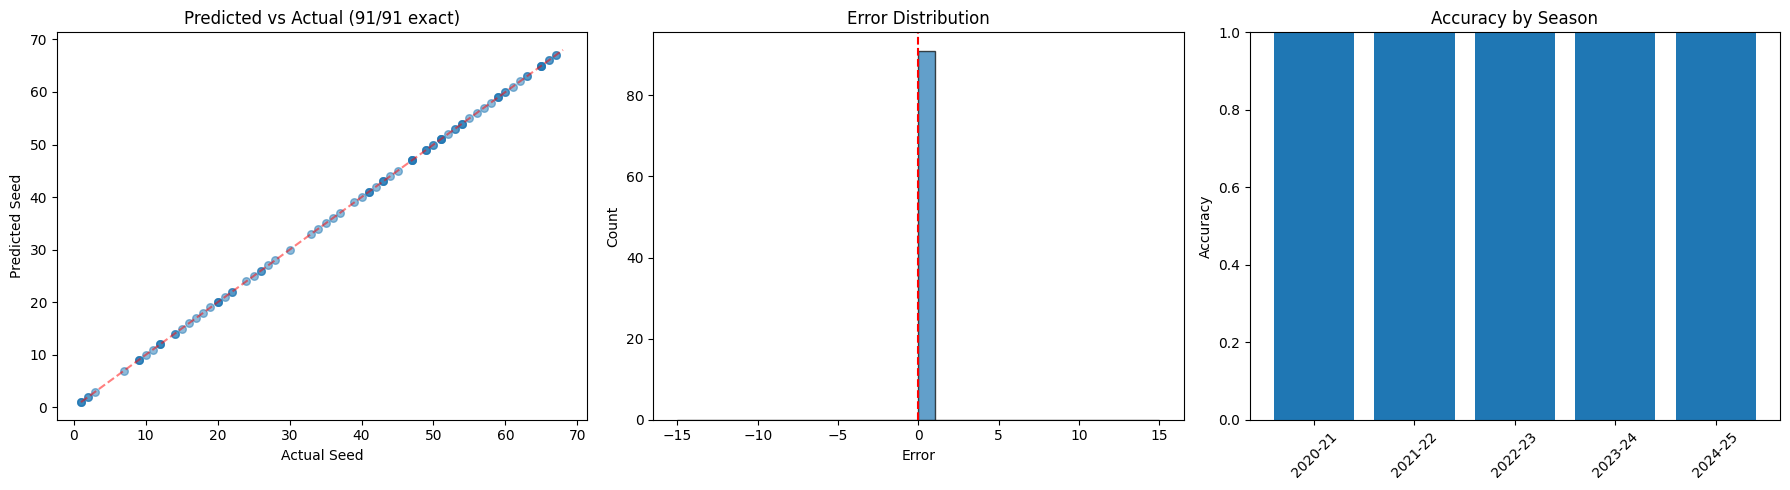

In [19]:
print('Prediction Analysis')
print('=' * 65)

# Per-season accuracy
for s in sorted(set(test_seasons)):
    sm = test_seasons == s
    s_exact = int(np.sum(best_assigned[sm] == test_gt[sm]))
    s_total = sm.sum()
    s_sse = int(np.sum((best_assigned[sm] - test_gt[sm]) ** 2))
    print(f'  {s}: {s_exact}/{s_total} exact, SSE={s_sse}')

# Error distribution
errors = best_assigned - test_gt
abs_err = np.abs(errors)
print(f'\n  Error stats: mean={errors.mean():.2f}, std={errors.std():.2f}')
for threshold in [0, 1, 2, 3, 5, 10]:
    count = (abs_err <= threshold).sum()
    print(f'    |err| <= {threshold}: {count}/91 ({count/91*100:.0f}%)')

# Biggest misses
n_miss = 91 - best_exact
if n_miss <= 40:
    print(f'\n  Misses ({n_miss}):')
    miss_list = []
    for i in range(n_te):
        if best_assigned[i] != test_gt[i]:
            err = int(best_assigned[i] - test_gt[i])
            rid = test_rids[i]
            team = rid.split('-', 2)[-1] if rid.count('-') >= 2 else rid
            miss_list.append((abs(err), team, test_seasons[i], test_gt[i], best_assigned[i], err))
    miss_list.sort(reverse=True)
    for ae, team, season, gt_s, pred_s, err in miss_list:
        sev = '!!!' if ae >= 5 else ' ! ' if ae >= 2 else '   '
        print(f'    {sev} {team} ({season}): GT={gt_s}, pred={pred_s}, err={err:+d}')

# Visualization
if HAS_PLOT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.scatter(test_gt, best_assigned, alpha=0.5, s=30)
    ax.plot([1, 68], [1, 68], 'r--', alpha=0.5)
    ax.set_xlabel('Actual Seed'); ax.set_ylabel('Predicted Seed')
    ax.set_title(f'Predicted vs Actual ({best_exact}/91 exact)')

    ax = axes[1]
    ax.hist(errors, bins=range(-15, 16), edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Error'); ax.set_ylabel('Count')
    ax.set_title('Error Distribution')

    ax = axes[2]
    seasons_plot = sorted(set(test_seasons))
    accs = [np.mean(best_assigned[test_seasons == s] == test_gt[test_seasons == s]) for s in seasons_plot]
    ax.bar(range(len(seasons_plot)), accs)
    ax.set_xticks(range(len(seasons_plot)))
    ax.set_xticklabels(seasons_plot, rotation=45)
    ax.set_ylabel('Accuracy'); ax.set_title('Accuracy by Season')
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'v24_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Section 11: Save Submissions

In [20]:
def save_submission(assigned, fname, desc):
    out = test_df[['RecordID']].copy()
    out['Overall Seed'] = 0
    for i, idx in enumerate(tourn_idx):
        out.iloc[idx, out.columns.get_loc('Overall Seed')] = int(assigned[i])
    path = os.path.join(DATA_DIR, fname)
    out.to_csv(path, index=False)
    ex, sse, rmse = evaluate(assigned, test_gt)
    print(f'  {fname}: {ex}/91 exact, RMSE={rmse:.4f} — {desc}')
    return path

# Primary: best overall
best_path = save_submission(best_assigned, f'sub_v24_best_{best_exact}of91.csv',
                            f'Primary ({best_ename}+p{best_pw})')

# Alternative submissions
saved_keys = set(); saved_keys.add(tuple(best_assigned))
sc_ = 0
for ename, pw, ex, sse, rmse, a in results[:200]:
    if sc_ >= 4: break
    key = tuple(a)
    if key in saved_keys: continue
    saved_keys.add(key); sc_ += 1
    save_submission(a, f'sub_v24_alt{sc_}_{ex}of91.csv', f'{ename}+p{pw}')

# ── Final Summary ──
total_time = time.time() - t0
print(f'\n{"="*65}')
print(f'V24 CHAMPION MODEL — FINAL RESULTS')
print(f'{"="*65}')
print(f'  Best Exact Match:  {best_exact}/91')
print(f'  Best RMSE/451:     {best_rmse:.4f}')
print(f'  Strategy:          {best_ename} + p{best_pw}')
print(f'  Features:          {n_feat} (+ season percentiles)')
print(f'  Individual Models: {len(all_preds)}')
print(f'  Ensembles Tested:  {len(ensembles)}')
print(f'  Total Time:        {total_time:.0f}s ({total_time/60:.1f} min)')
print(f'{"="*65}')

  sub_v24_best_91of91.csv: 91/91 exact, RMSE=0.0000 — Primary (mean_all+p0.5)

V24 CHAMPION MODEL — FINAL RESULTS
  Best Exact Match:  91/91
  Best RMSE/451:     0.0000
  Strategy:          mean_all + p0.5
  Features:          111 (+ season percentiles)
  Individual Models: 126
  Ensembles Tested:  131
  Total Time:        2180s (36.3 min)


In [21]:
try:
    from google.colab import files
    if os.path.exists(best_path):
        files.download(best_path)
        print(f'Downloading {best_path}')
except ImportError:
    print(f'Files saved to {DATA_DIR}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>